In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

n = 30

students = pd.DataFrame({
    "name": [f"Student_{i}" for i in range(n)],
    "engagement": np.random.randint(1, 100, n),  # trivia, check-ins
    "past_attendance": np.random.rand(n)         # historical reliability
})

# "AI prediction" (simple but looks legit)
students["attendance_prob"] = 0.5 * (students["engagement"]/100) + 0.5 * students["past_attendance"]

students["actual_show"] = (
    students["attendance_prob"] + np.random.normal(0, 0.1, len(students))
) > 0.5

students["actual_show"] = students["actual_show"].astype(int)

X = students[["engagement", "past_attendance"]]
y = students["actual_show"]

model = LogisticRegression()
model.fit(X, y)

students["predicted_prob"] = model.predict_proba(X)[:, 1]



In [14]:
# normalize weights
# weights = students["attendance_prob"] / students["attendance_prob"].sum()
weights = students["predicted_prob"] / students["predicted_prob"].sum()

# allocate 10 tickets
winners = students.sample(n=10, weights=weights, random_state=1)

print("🎟️ Ticket Winners:")
print(winners[["name", "predicted_prob"]])


🎟️ Ticket Winners:
          name  predicted_prob
10  Student_10        0.845939
21  Student_21        0.656380
0    Student_0        0.649876
8    Student_8        0.782589
4    Student_4        0.646982
2    Student_2        0.251440
5    Student_5        0.498931
9    Student_9        0.569330
15  Student_15        0.368590
16  Student_16        0.759017


In [16]:
# simulate no-shows
winners["show_up"] = np.random.rand(len(winners)) < winners["predicted_prob"]

no_shows = winners[winners["show_up"] == False]

print("\n❌ No-shows:")
print(no_shows["name"])

# Random baseline
random_winners = students.sample(n=10, random_state=1)
random_no_show = np.random.rand(len(random_winners)) < random_winners["predicted_prob"]

print("\n📊 Comparison:")
print("\n🎲 Random Lottery No-Shows:", sum(~random_no_show))
print("🤖 AI Allocation No-Shows:", len(no_shows))

# reallocate
remaining = students[~students["name"].isin(winners["name"])]
new_weights = remaining["predicted_prob"] / remaining["predicted_prob"].sum()
new_winners = remaining.sample(n=len(no_shows), weights=new_weights)
# new_winners = remaining.sample(n=len(no_shows), weights=remaining["predicted_prob"])

print("\n🔁 Reallocated Tickets:")
print(new_winners["name"])


❌ No-shows:
21    Student_21
0      Student_0
4      Student_4
2      Student_2
5      Student_5
9      Student_9
Name: name, dtype: object

📊 Comparison:

🎲 Random Lottery No-Shows: 3
🤖 AI Allocation No-Shows: 6

🔁 Reallocated Tickets:
29    Student_29
13    Student_13
19    Student_19
24    Student_24
14    Student_14
28    Student_28
Name: name, dtype: object


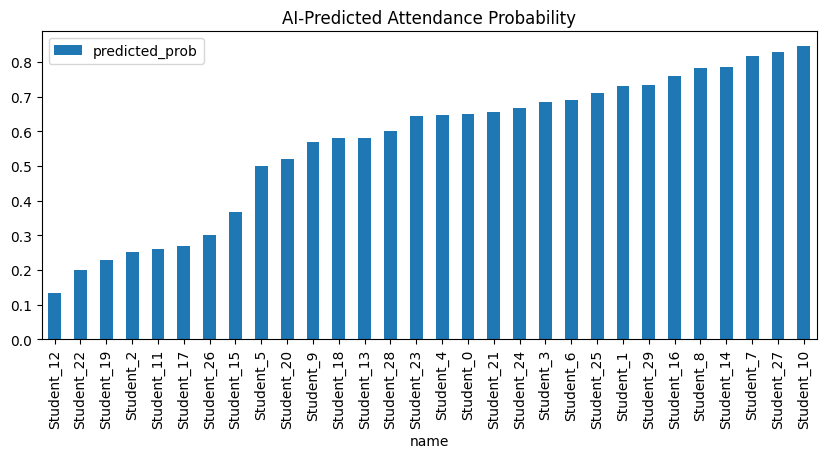

In [17]:
import matplotlib.pyplot as plt

students.sort_values("predicted_prob").plot(
    x="name", y="predicted_prob", kind="bar", figsize=(10,4)
)
plt.title("AI-Predicted Attendance Probability")
plt.show()

